# 使用Pytorch进行函数拟合

函数定义为 f(x) = sin(x) - x
这个函数具有非线性周期性以及线性下降趋势。

## 数据准备

In [1]:
import numpy as np
import torch

from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import matplotlib.pyplot as plt

# 生成数据
x = np.linspace(-2 * np.pi, 2 * np.pi, 400)  # 输入范围 [-2π, 2π]
y = np.sin(x) - x  # 目标函数 sin(x) - x

# 将数据转换为 PyTorch 张量所需的形状
X = np.expand_dims(x, axis=1)  # (400, 1)
Y = y.reshape(400, -1)  # (400, 1)

# 构建数据集与数据加载器
dataset = TensorDataset(torch.tensor(X, dtype=torch.float), torch.tensor(Y, dtype=torch.float))
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

## 神经网络结构

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=1, out_features=20), nn.ReLU(),  # 增加隐藏层神经元数量
            nn.Linear(20, 100), nn.ReLU(),
            nn.Linear(100, 50), nn.ReLU(),
            nn.Linear(50, 1)  # 输出层
        )

    def forward(self, input: torch.FloatTensor):
        return self.net(input)

net = Net()
# 定义优化器与损失函数
optim = torch.optim.Adam(net.parameters(), lr=0.001)
Loss = nn.MSELoss()

## 训练数据

In [3]:
# 开始训练
for epoch in range(2000):  # 增加训练次数
    loss = None
    for batch_x, batch_y in dataloader:
        y_predict = net(batch_x)
        loss = Loss(y_predict, batch_y)
        optim.zero_grad()
        loss.backward()
        optim.step()
    # 每 100 次打印一次日志
    if (epoch + 1) % 100 == 0:
        print("step: {0} , loss: {1}".format(epoch + 1, loss.item()))

step: 100 , loss: 0.10833948850631714
step: 200 , loss: 0.05974738299846649
step: 300 , loss: 0.013650454580783844
step: 400 , loss: 0.003657623426988721
step: 500 , loss: 0.0012126399669796228
step: 600 , loss: 0.0006014849641360343
step: 700 , loss: 0.0007128092693164945
step: 800 , loss: 0.000714033143594861
step: 900 , loss: 0.00014395425387192518
step: 1000 , loss: 0.00013632465561386198
step: 1100 , loss: 0.0001814409188227728
step: 1200 , loss: 0.0001912305160658434
step: 1300 , loss: 0.0003434326790738851
step: 1400 , loss: 7.343406468862668e-05
step: 1500 , loss: 0.0013819155283272266
step: 1600 , loss: 0.0001559974334668368
step: 1700 , loss: 0.0001412576821167022
step: 1800 , loss: 0.00048472610069438815
step: 1900 , loss: 0.00042422834667377174
step: 2000 , loss: 0.0001540805824333802


## 预测与可视化结果

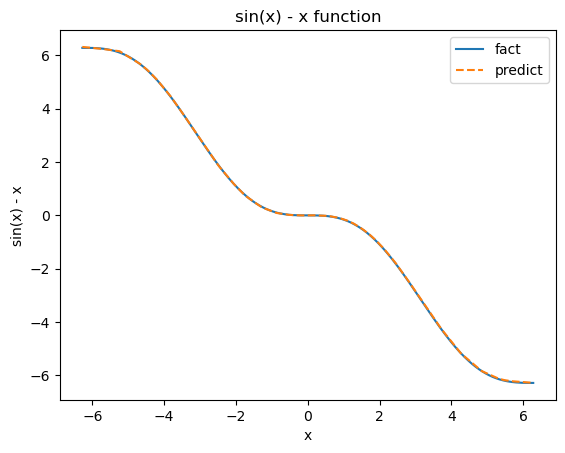

In [7]:
# 使用训练好的模型进行预测
predict = net(torch.tensor(X, dtype=torch.float))

# 绘图展示预测的和真实数据之间的差异
plt.plot(x, y, label="fact")  # 真实值曲线
plt.plot(x, predict.detach().numpy(), label="predict", linestyle="--")  # 预测值曲线
plt.title("sin(x) - x function")
plt.xlabel("x")
plt.ylabel("sin(x) - x")
plt.legend()
plt.savefig(fname="PyTorch_result.png", dpi=300)  # 保存图像
plt.show()